# Statistical Foundations & Predictive Maintenance Lab
This notebook performs cleaning, hypothesis testing, feature engineering, modeling, and RUL estimation on the synthetic PdM dataset.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = '../data/pdm_synthetic_sensor_data.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df.shape, df.head()

((2640, 16),
           timestamp  asset_id  depot  shift  asset_age_months  vibration_g  \
 0  01/01/2026 00:00  PUMP-001  North    Day                15       1.3056   
 1  01/01/2026 06:00  PUMP-001  North  Night                15       1.8329   
 2  01/01/2026 12:00  PUMP-001  North    Day                15       1.7601   
 3  01/01/2026 18:00  PUMP-001  North  Night                15       2.0155   
 4  02/01/2026 00:00  PUMP-001  North    Day                15       1.3916   
 
    temperature_c  pressure_psi  acoustic_db  motor_current_a  error_events  \
 0        64.4815      123.4455      69.9614          34.8057             0   
 1        65.2009      121.4905      70.8481          34.6576             1   
 2        63.9732      123.0420      69.1901          36.7452             0   
 3        63.6278      122.7399      68.1283          36.8624             0   
 4        65.4224      127.2597      71.2493          35.0683             0   
 
    constant_sensor  time_to_failur

In [2]:
# Descriptive statistics and cleaning checks
numeric = df.select_dtypes(include='number')
summary = numeric.describe(percentiles=[.05, .25, .5, .75, .95]).T
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
missing_counts = df.isna().sum().sort_values(ascending=False)
summary.head(), constant_columns, missing_counts.head()

(                   count        mean        std      min         5%  \
 asset_age_months  2640.0   52.541667  29.065758   8.0000    9.00000   
 vibration_g       2640.0    2.208835   0.868509   0.6768    1.25198   
 temperature_c     2640.0   64.845955   6.913448  51.3812   55.90679   
 pressure_psi      2631.0  117.076871   8.271105  88.1527  102.32470   
 acoustic_db       2631.0   71.286330   3.366274  61.6087   66.62165   
 
                          25%        50%         75%        95%        max  
 asset_age_months   28.000000   47.00000   83.500000   94.00000   95.00000  
 vibration_g         1.676925    1.95595    2.415475    4.15366   10.48078  
 temperature_c      60.258075   63.86970   67.580875   78.53010  122.98290  
 pressure_psi      111.757400  117.62790  123.202350  129.52805  138.19850  
 acoustic_db        68.972450   70.78010   73.121700   77.69805   84.31110  ,
 ['constant_sensor'],
 pressure_psi    9
 acoustic_db     9
 timestamp       0
 asset_id        0
 depo

In [3]:
# Three-standard-deviation outlier flags
z = (numeric - numeric.mean()) / numeric.std(ddof=0)
outlier_counts = (z.abs() > 3).sum().sort_values(ascending=False)
outlier_counts.head(10)

error_events             37
motor_current_a          21
acoustic_db              16
vibration_g              12
temperature_c             9
pressure_psi              7
asset_age_months          0
constant_sensor           0
time_to_failure_hours     0
failure_within_7_days     0
dtype: int64

In [5]:
# Independent t-test: Day vs Night vibration levels
day = df.loc[df['shift'] == 'Day', 'vibration_g'].dropna()
night = df.loc[df['shift'] == 'Night', 'vibration_g'].dropna()
t_stat, p_value = stats.ttest_ind(day, night, equal_var=False)
print({'t_statistic': round(t_stat, 4), 'p_value': round(p_value, 6), 'day_mean': day.mean(), 'night_mean': night.mean()})
print('Reject H0: shift means differ' if p_value < 0.05 else 'Fail to reject H0')

{'t_statistic': -2.743, 'p_value': 0.006131, 'day_mean': 2.167535760054533, 'night_mean': 2.260484722932651}
Reject H0: shift means differ


/tmp/ipykernel_38928/2033459520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="shift", y="vibration_g", data=df, palette="Set2")


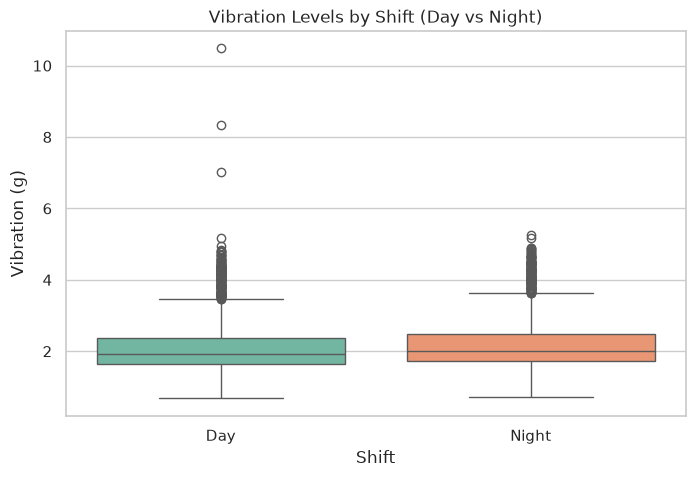

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="shift", y="vibration_g", data=df, palette="Set2")
plt.title("Vibration Levels by Shift (Day vs Night)")
plt.xlabel("Shift")
plt.ylabel("Vibration (g)")
plt.show()

In [8]:
# ANOVA: throughput proxy across depots using pressure
samples = [g['pressure_psi'].dropna() for _, g in df.groupby('depot')]
f_stat, anova_p = stats.f_oneway(*samples)
print({'f_statistic': round(f_stat, 4), 'p_value': round(anova_p, 6)})

{'f_statistic': 42.2991, 'p_value': 0.0}


/tmp/ipykernel_38928/704575859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


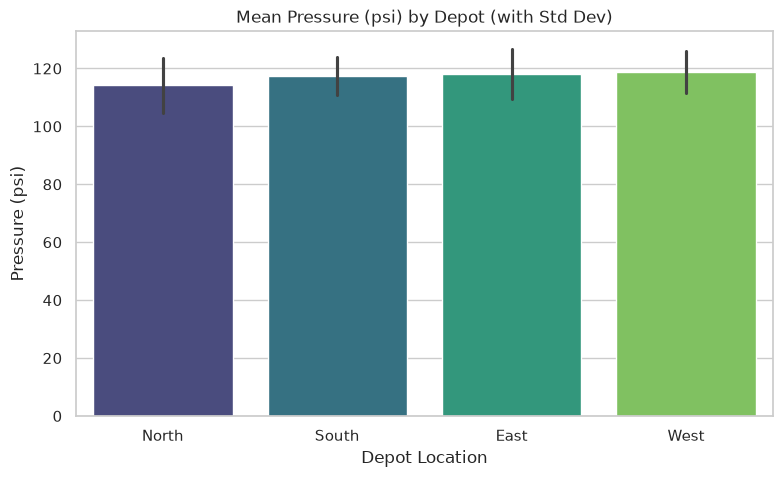

In [6]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x="depot",
    y="pressure_psi",
    data=df,
    estimator=np.mean,
    errorbar="sd",
    palette="viridis",
)
plt.title("Mean Pressure (psi) by Depot (with Std Dev)")
plt.xlabel("Depot Location")
plt.ylabel("Pressure (psi)")
plt.show()

In [8]:
# Feature engineering: rolling mean, RMS, and peak-to-peak
work = df.sort_values(['asset_id', 'timestamp']).copy()
work['vibration_roll_mean_6'] = work.groupby('asset_id')['vibration_g'].transform(lambda s: s.rolling(6, min_periods=1).mean())
work['vibration_rms_6'] = work.groupby('asset_id')['vibration_g'].transform(lambda s: np.sqrt(s.pow(2).rolling(6, min_periods=1).mean()))
work['vibration_peak_to_peak_6'] = work.groupby('asset_id')['vibration_g'].transform(lambda s: s.rolling(6, min_periods=1).max() - s.rolling(6, min_periods=1).min())
work[['asset_id','timestamp','vibration_g','vibration_roll_mean_6','vibration_rms_6','vibration_peak_to_peak_6']].head(10)

,asset_id,timestamp,vibration_g,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6
0,PUMP-001,01/01/2026 00:00,1.3056,1.305600,1.305600,0.0000
1,PUMP-001,01/01/2026 06:00,1.8329,1.569250,1.591244,0.5273
2,PUMP-001,01/01/2026 12:00,1.7601,1.632867,1.649451,0.5273
3,PUMP-001,01/01/2026 18:00,2.0155,1.728525,1.748164,0.7099
4,PUMP-001,02/01/2026 00:00,1.3916,1.661140,1.682906,0.7099
5,PUMP-001,02/01/2026 06:00,1.6969,1.667100,1.685246,0.7099
6,PUMP-001,02/01/2026 12:00,1.5453,1.707050,1.718705,0.6239
7,PUMP-001,02/01/2026 18:00,1.6593,1.678117,1.689055,0.6239
8,PUMP-001,03/01/2026 00:00,1.3104,1.603167,1.619498,0.7051
9,PUMP-001,03/01/2026 06:00,1.7426,1.557683,1.565836,0.4322


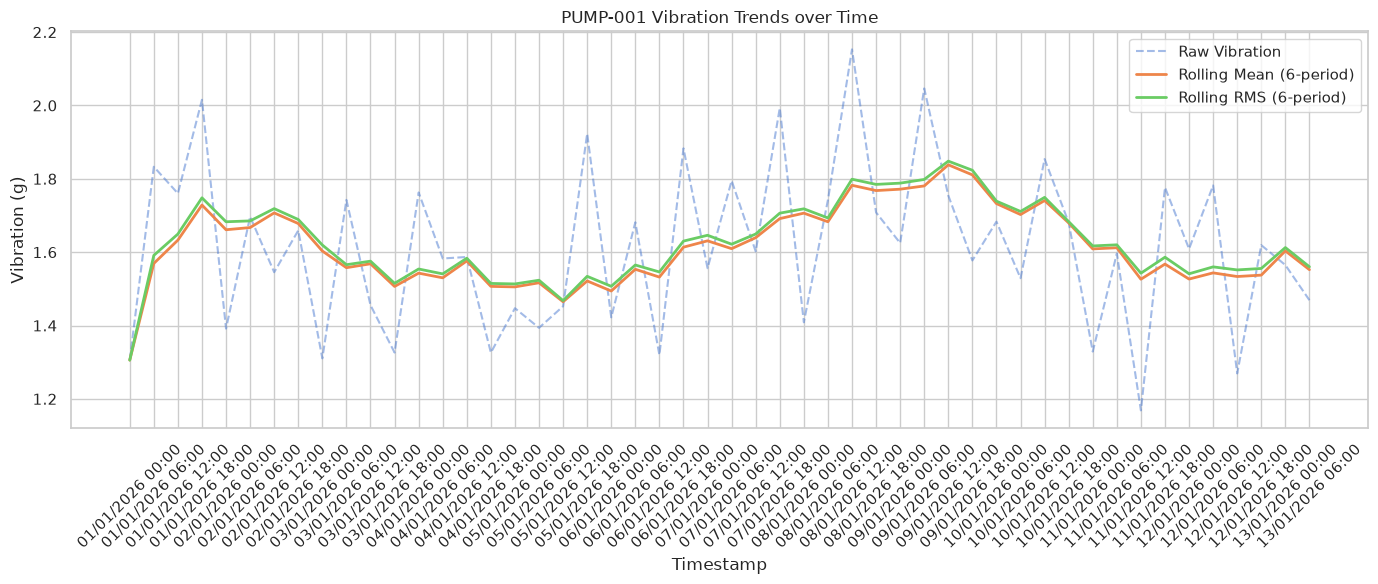

In [9]:
# Filter for single asset (e.g., PUMP-001)
pump_data = work[work["asset_id"] == "PUMP-001"].head(50)

plt.figure(figsize=(14, 6))
plt.plot(
    pump_data["timestamp"],
    pump_data["vibration_g"],
    label="Raw Vibration",
    alpha=0.5,
    linestyle="--",
)
plt.plot(
    pump_data["timestamp"],
    pump_data["vibration_roll_mean_6"],
    label="Rolling Mean (6-period)",
    linewidth=2,
)
plt.plot(
    pump_data["timestamp"],
    pump_data["vibration_rms_6"],
    label="Rolling RMS (6-period)",
    linewidth=2,
)

plt.title("PUMP-001 Vibration Trends over Time")
plt.xlabel("Timestamp")
plt.ylabel("Vibration (g)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Bagged tree classifier: predict failure within 7 days
features = ['asset_age_months','vibration_g','temperature_c','pressure_psi','acoustic_db','motor_current_a','error_events','vibration_roll_mean_6','vibration_rms_6','vibration_peak_to_peak_6']
model_df = work[features + ['failure_within_7_days']].dropna()
X_train, X_test, y_train, y_test = train_test_split(model_df[features], model_df['failure_within_7_days'], test_size=0.25, random_state=42, stratify=model_df['failure_within_7_days'])
clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5, random_state=42), n_estimators=40, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['No near failure','Near failure']))

[[485   5]
 [ 30 136]]
                 precision    recall  f1-score   support

No near failure       0.94      0.99      0.97       490
   Near failure       0.96      0.82      0.89       166

       accuracy                           0.95       656
      macro avg       0.95      0.90      0.93       656
   weighted avg       0.95      0.95      0.95       656



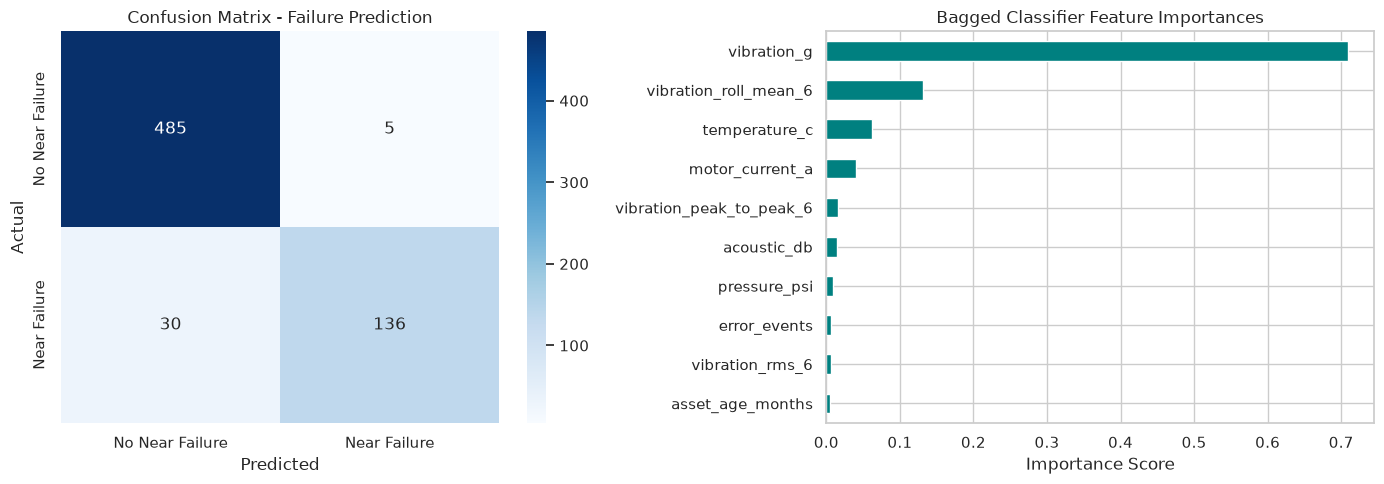

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No Near Failure", "Near Failure"],
    yticklabels=["No Near Failure", "Near Failure"],
)
axes[0].set_title("Confusion Matrix - Failure Prediction")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# 2. Feature Importances (Averaged across bagged trees)
importances = np.mean(
    [tree.feature_importances_ for tree in clf.estimators_], axis=0
)
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

feat_imp.plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Bagged Classifier Feature Importances")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [12]:
# Remaining Useful Life regression baseline
reg = LinearRegression()
rul_df = work[features + ['time_to_failure_hours']].dropna()
X_train, X_test, y_train, y_test = train_test_split(rul_df[features], rul_df['time_to_failure_hours'], test_size=0.25, random_state=42)
reg.fit(X_train, y_train)
rul_pred = reg.predict(X_test)

print({'mae_hours': round(mean_absolute_error(y_test, rul_pred), 2)})

{'mae_hours': 109.02}
